# AgroESG Analytics — Correção de Escopo
## 01 — Exploração dos Dados IBGE/PAM

**Fonte:** IBGE — Pesquisa Agrícola Municipal (PAM)  
**Tabela SIDRA:** 1612  
**Cultura do projeto:** Soja (em grão)  
**Regiões do projeto:** Centro-Oeste e Sul  
**Período Processed:** 2018–2024  
**Período Curated:** 2019–2024  
**Granularidade:** Município

### Objetivos
- interpretar e tratar a base PAM;
- manter somente registros de soja;
- restringir o recorte territorial a Centro-Oeste e Sul;
- preservar apenas os municípios pertencentes a DF, GO, MT, MS, PR, RS e SC;
- produzir as camadas `databases_processed` e `databases_curated`;
- preparar a base para integração com o MapBiomas Solo.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 150)


In [2]:
# Raiz do projeto
PROJECT_ROOT = Path.cwd().parent

RAW_DIR = PROJECT_ROOT / "data" / "raw" / "ibge_pam"
PROCESSED_DIR = PROJECT_ROOT / "data" / "databases_processed" / "ibge_pam"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print("Projeto:", PROJECT_ROOT)
print("Entrada:", RAW_DIR)
print("Saída:", PROCESSED_DIR)


Projeto: C:\Users\Elaine Cristina\Downloads\agroesg-analytics_correcao\agroesg-analytics_correcao
Entrada: C:\Users\Elaine Cristina\Downloads\agroesg-analytics_correcao\agroesg-analytics_correcao\data\raw\ibge_pam
Saída: C:\Users\Elaine Cristina\Downloads\agroesg-analytics_correcao\agroesg-analytics_correcao\data\databases_processed\ibge_pam


In [3]:
arquivos = list(RAW_DIR.glob("*"))

for arquivo in arquivos:
    tamanho_mb = arquivo.stat().st_size / (1024 ** 2)
    print(f"{arquivo.name} -> {tamanho_mb:.2f} MB")


.gitkeep -> 0.00 MB
pam_1612_soja_cana_municipios_2018_2024.csv -> 2.87 MB


In [4]:
arquivos_pam = sorted(RAW_DIR.glob("*.csv"))

assert len(arquivos_pam) == 1, (
    f"Esperado 1 CSV em {RAW_DIR}, mas foram encontrados {len(arquivos_pam)}."
)

arquivo_pam = arquivos_pam[0]

print("Arquivo PAM selecionado:")
print(arquivo_pam)

with open(arquivo_pam, "r", encoding="utf-8-sig") as arquivo:
    for _ in range(5):
        print(arquivo.readline())


Arquivo PAM selecionado:
C:\Users\Elaine Cristina\Downloads\agroesg-analytics_correcao\agroesg-analytics_correcao\data\raw\ibge_pam\pam_1612_soja_cana_municipios_2018_2024.csv
"Tabela 1612 - Área plantada, área colhida, quantidade produzida, rendimento médio e valor da produção das lavouras temporárias"

"Variável - Área plantada (Hectares)"

"Cód.";"Município";"Ano x Produto das lavouras temporárias"

"Cód.";"Município";"2018";;"2019";;"2020";;"2021";;"2022";;"2023";;"2024"

"Cód.";"Município";"Cana-de-açúcar";"Soja (em grão)";"Cana-de-açúcar";"Soja (em grão)";"Cana-de-açúcar";"Soja (em grão)";"Cana-de-açúcar";"Soja (em grão)";"Cana-de-açúcar";"Soja (em grão)";"Cana-de-açúcar";"Soja (em grão)";"Cana-de-açúcar";"Soja (em grão)"



In [5]:
with open(arquivo_pam, "r", encoding="utf-8-sig") as arquivo:
    linhas = arquivo.readlines()

for i, linha in enumerate(linhas):
    if "Variável -" in linha:
        print(i, linha.strip())


1 "Variável - Área plantada (Hectares)"
5571 "Variável - Área colhida (Hectares)"
11141 "Variável - Quantidade produzida (Toneladas)"
16711 "Variável - Rendimento médio da produção (Quilogramas por Hectare)"
22281 "Variável - Valor da produção (Mil Reais)"


In [6]:
for i, linha in enumerate(linhas):
    if (
        "Área plantada" in linha
        or "Área colhida" in linha
        or "Quantidade produzida" in linha
        or "Rendimento médio" in linha
        or "Valor da produção" in linha
    ):
        print(i, linha.strip())


0 "Tabela 1612 - Área plantada, área colhida, quantidade produzida, rendimento médio e valor da produção das lavouras temporárias"
1 "Variável - Área plantada (Hectares)"
5570 "Tabela 1612 - Área plantada, área colhida, quantidade produzida, rendimento médio e valor da produção das lavouras temporárias"
5571 "Variável - Área colhida (Hectares)"
11140 "Tabela 1612 - Área plantada, área colhida, quantidade produzida, rendimento médio e valor da produção das lavouras temporárias"
11141 "Variável - Quantidade produzida (Toneladas)"
16710 "Tabela 1612 - Área plantada, área colhida, quantidade produzida, rendimento médio e valor da produção das lavouras temporárias"
16711 "Variável - Rendimento médio da produção (Quilogramas por Hectare)"
22280 "Tabela 1612 - Área plantada, área colhida, quantidade produzida, rendimento médio e valor da produção das lavouras temporárias"
22281 "Variável - Valor da produção (Mil Reais)"
27856 "6 - Valores para a categoria Total indisponíveis para as variáveis

In [7]:
print("Total de linhas do arquivo:", len(linhas))


Total de linhas do arquivo: 27881


## 7. Reconstrução da base PAM

A exportação da Tabela 1612 contém cinco blocos de variáveis agrícolas.
Nesta correção, o parser extrai exclusivamente a série anual de **soja** e, após a identificação da UF, mantém somente os municípios das regiões **Centro-Oeste** e **Sul**.


In [8]:
import csv
import pandas as pd

variaveis = {
    "Área plantada": "area_plantada_ha",
    "Área colhida": "area_colhida_ha",
    "Quantidade produzida": "quantidade_produzida_t",
    "Rendimento médio": "rendimento_medio_kg_ha",
    "Valor da produção": "valor_producao_mil_reais"
}

anos = list(range(2018, 2025))
culturas = ["soja"]


In [9]:
registros = []
variavel_atual = None

with open(arquivo_pam, "r", encoding="utf-8-sig", newline="") as arquivo:
    leitor = csv.reader(arquivo, delimiter=";")

    for linha in leitor:
        if not linha:
            continue

        primeira_coluna = linha[0].strip()

        if "Variável - Área plantada" in primeira_coluna:
            variavel_atual = "area_plantada_ha"
            continue
        elif "Variável - Área colhida" in primeira_coluna:
            variavel_atual = "area_colhida_ha"
            continue
        elif "Variável - Quantidade produzida" in primeira_coluna:
            variavel_atual = "quantidade_produzida_t"
            continue
        elif "Variável - Rendimento médio" in primeira_coluna:
            variavel_atual = "rendimento_medio_kg_ha"
            continue
        elif "Variável - Valor da produção" in primeira_coluna:
            variavel_atual = "valor_producao_mil_reais"
            continue

        if variavel_atual is None:
            continue

        codigo = primeira_coluna
        if not (codigo.isdigit() and len(codigo) == 7):
            continue

        # A exportação utilizada possui código, município e dois valores por ano.
        # A série de soja está na segunda posição de cada par anual.
        if len(linha) < 16:
            continue

        municipio_com_uf = linha[1].strip()
        valores = linha[2:16]

        for i, ano in enumerate(anos):
            valor_soja = valores[i * 2 + 1]

            registros.append({
                "codigo_ibge": codigo,
                "municipio_original": municipio_com_uf,
                "ano": ano,
                "cultura": "soja",
                "variavel": variavel_atual,
                "valor": valor_soja
            })


In [10]:
df_pam = pd.DataFrame(registros)

print("Dimensão:", df_pam.shape)

df_pam.head(10)


Dimensão: (194705, 6)


,codigo_ibge,municipio_original,ano,cultura,variavel,valor
0,1100015,Alta Floresta D'Oeste (RO),2018,soja,area_plantada_ha,450
1,1100015,Alta Floresta D'Oeste (RO),2019,soja,area_plantada_ha,450
2,1100015,Alta Floresta D'Oeste (RO),2020,soja,area_plantada_ha,450
3,1100015,Alta Floresta D'Oeste (RO),2021,soja,area_plantada_ha,1072
4,1100015,Alta Floresta D'Oeste (RO),2022,soja,area_plantada_ha,1117
5,1100015,Alta Floresta D'Oeste (RO),2023,soja,area_plantada_ha,1318
6,1100015,Alta Floresta D'Oeste (RO),2024,soja,area_plantada_ha,1697
7,1100023,Ariquemes (RO),2018,soja,area_plantada_ha,5600
8,1100023,Ariquemes (RO),2019,soja,area_plantada_ha,7893
9,1100023,Ariquemes (RO),2020,soja,area_plantada_ha,7782


In [11]:
df_pam["variavel"].value_counts()


variavel
area_plantada_ha            38941
area_colhida_ha             38941
quantidade_produzida_t      38941
rendimento_medio_kg_ha      38941
valor_producao_mil_reais    38941
Name: count, dtype: int64

In [12]:
print("Municípios:", df_pam["codigo_ibge"].nunique())
print("Anos:", sorted(df_pam["ano"].unique()))
print("Culturas:", df_pam["cultura"].unique())
print("Variáveis:", df_pam["variavel"].unique())


Municípios: 5563
Anos: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Culturas: ['soja']
Variáveis: ['area_plantada_ha' 'area_colhida_ha' 'quantidade_produzida_t'
 'rendimento_medio_kg_ha' 'valor_producao_mil_reais']


In [13]:
df_pam["valor"] = (
    df_pam["valor"]
    .astype(str)
    .str.strip()
)

df_pam["valor"] = df_pam["valor"].replace({
    "...": pd.NA,
    "-": pd.NA,
    "X": pd.NA,
    "": pd.NA
})

df_pam["valor"] = pd.to_numeric(
    df_pam["valor"],
    errors="coerce"
)

df_pam["valor"].dtype


dtype('float64')

In [14]:
df_pam["uf"] = (
    df_pam["municipio_original"]
    .str.extract(r"\(([A-Z]{2})\)$")
)

df_pam["municipio"] = (
    df_pam["municipio_original"]
    .str.replace(r"\s*\([A-Z]{2}\)$", "", regex=True)
    .str.strip()
)

ufs_projeto = ["DF", "GO", "MT", "MS", "PR", "RS", "SC"]

df_pam = df_pam[df_pam["uf"].isin(ufs_projeto)].copy()

print("Municípios após recorte territorial:", df_pam["codigo_ibge"].nunique())
print("UFs:", sorted(df_pam["uf"].unique()))

df_pam[["codigo_ibge", "municipio", "uf"]].head()


Municípios após recorte territorial: 1658
UFs: ['DF', 'GO', 'MS', 'MT', 'PR', 'RS', 'SC']


,codigo_ibge,municipio,uf
27335,4100103,Abatiá,PR
27336,4100103,Abatiá,PR
27337,4100103,Abatiá,PR
27338,4100103,Abatiá,PR
27339,4100103,Abatiá,PR


In [15]:
pam_final = (
    df_pam
    .pivot_table(
        index=[
            "codigo_ibge",
            "municipio",
            "uf",
            "ano",
            "cultura"
        ],
        columns="variavel",
        values="valor",
        aggfunc="first"
    )
    .reset_index()
)

pam_final.columns.name = None

pam_final.head(10)


,codigo_ibge,municipio,uf,ano,cultura,area_colhida_ha,area_plantada_ha,quantidade_produzida_t,rendimento_medio_kg_ha,valor_producao_mil_reais
0,4100103,Abatiá,PR,2018,soja,10220.0,10220.0,26981.0,2640.0,29517.0
1,4100103,Abatiá,PR,2019,soja,10570.0,10570.0,36784.0,3480.0,43387.0
2,4100103,Abatiá,PR,2020,soja,10470.0,10470.0,36435.0,3480.0,50268.0
3,4100103,Abatiá,PR,2021,soja,10220.0,10220.0,27727.0,2713.0,69682.0
4,4100103,Abatiá,PR,2022,soja,10470.0,10470.0,37064.0,3540.0,114457.0
5,4100103,Abatiá,PR,2023,soja,9960.0,9960.0,35856.0,3600.0,94498.0
6,4100103,Abatiá,PR,2024,soja,9600.0,9600.0,34560.0,3600.0,66365.0
7,4100202,Adrianópolis,PR,2023,soja,20.0,20.0,70.0,3500.0,206.0
8,4100202,Adrianópolis,PR,2024,soja,18.0,18.0,61.0,3389.0,132.0
9,4100301,Agudos do Sul,PR,2018,soja,956.0,956.0,3537.0,3700.0,3831.0


In [16]:
print("Dimensão final:", pam_final.shape)

print(
    "Municípios:",
    pam_final["codigo_ibge"].nunique()
)

print(
    "Anos:",
    sorted(pam_final["ano"].unique())
)

print(
    "Culturas:",
    pam_final["cultura"].unique()
)

pam_final.head()


Dimensão final: (10075, 10)
Municípios: 1505
Anos: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Culturas: ['soja']


,codigo_ibge,municipio,uf,ano,cultura,area_colhida_ha,area_plantada_ha,quantidade_produzida_t,rendimento_medio_kg_ha,valor_producao_mil_reais
0,4100103,Abatiá,PR,2018,soja,10220.0,10220.0,26981.0,2640.0,29517.0
1,4100103,Abatiá,PR,2019,soja,10570.0,10570.0,36784.0,3480.0,43387.0
2,4100103,Abatiá,PR,2020,soja,10470.0,10470.0,36435.0,3480.0,50268.0
3,4100103,Abatiá,PR,2021,soja,10220.0,10220.0,27727.0,2713.0,69682.0
4,4100103,Abatiá,PR,2022,soja,10470.0,10470.0,37064.0,3540.0,114457.0


In [17]:
pam_final[
    pam_final["codigo_ibge"] == "1100015"
].sort_values(
    ["ano", "cultura"]
)


,codigo_ibge,municipio,uf,ano,cultura,area_colhida_ha,area_plantada_ha,quantidade_produzida_t,rendimento_medio_kg_ha,valor_producao_mil_reais


## 8. Validação da base processada

Nesta etapa são verificadas a unicidade das chaves,
consistência das variáveis agrícolas, valores ausentes e
coerência entre produção, área colhida e rendimento.


In [18]:
duplicados = pam_final.duplicated(
    subset=[
        "codigo_ibge",
        "ano",
        "cultura"
    ]
).sum()

print("Registros duplicados:", duplicados)


Registros duplicados: 0


In [19]:
nulos = (
    pam_final
    .isna()
    .sum()
    .sort_values(ascending=False)
)

nulos


area_colhida_ha             5
quantidade_produzida_t      5
rendimento_medio_kg_ha      5
valor_producao_mil_reais    5
codigo_ibge                 0
municipio                   0
uf                          0
ano                         0
cultura                     0
area_plantada_ha            0
dtype: int64

In [20]:
percentual_nulos = (
    pam_final
    .isna()
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

percentual_nulos


area_colhida_ha             0.05
quantidade_produzida_t      0.05
rendimento_medio_kg_ha      0.05
valor_producao_mil_reais    0.05
codigo_ibge                 0.00
municipio                   0.00
uf                          0.00
ano                         0.00
cultura                     0.00
area_plantada_ha            0.00
dtype: float64

In [21]:
colunas_numericas = [
    "area_plantada_ha",
    "area_colhida_ha",
    "quantidade_produzida_t",
    "rendimento_medio_kg_ha",
    "valor_producao_mil_reais"
]

for coluna in colunas_numericas:
    negativos = (pam_final[coluna] < 0).sum()

    print(
        coluna,
        "-> valores negativos:",
        negativos
    )


area_plantada_ha -> valores negativos: 0
area_colhida_ha -> valores negativos: 0
quantidade_produzida_t -> valores negativos: 0
rendimento_medio_kg_ha -> valores negativos: 0
valor_producao_mil_reais -> valores negativos: 0


In [22]:
pam_final["rendimento_calculado_kg_ha"] = (
    pam_final["quantidade_produzida_t"] * 1000
    / pam_final["area_colhida_ha"]
)


In [23]:
pam_final["diferenca_rendimento_pct"] = (
    (
        pam_final["rendimento_calculado_kg_ha"]
        - pam_final["rendimento_medio_kg_ha"]
    ).abs()
    /
    pam_final["rendimento_medio_kg_ha"]
    * 100
)


In [24]:
pam_final[
    [
        "municipio",
        "uf",
        "ano",
        "cultura",
        "area_colhida_ha",
        "quantidade_produzida_t",
        "rendimento_medio_kg_ha",
        "rendimento_calculado_kg_ha",
        "diferenca_rendimento_pct"
    ]
].head(20)


,municipio,uf,ano,cultura,area_colhida_ha,quantidade_produzida_t,rendimento_medio_kg_ha,rendimento_calculado_kg_ha,diferenca_rendimento_pct
0,Abatiá,PR,2018,soja,10220.0,26981.0,2640.0,2640.019569,0.000741
1,Abatiá,PR,2019,soja,10570.0,36784.0,3480.0,3480.037843,0.001087
2,Abatiá,PR,2020,soja,10470.0,36435.0,3480.0,3479.942693,0.001647
3,Abatiá,PR,2021,soja,10220.0,27727.0,2713.0,2713.013699,0.000505
4,Abatiá,PR,2022,soja,10470.0,37064.0,3540.0,3540.019102,0.000540
5,Abatiá,PR,2023,soja,9960.0,35856.0,3600.0,3600.000000,0.000000
6,Abatiá,PR,2024,soja,9600.0,34560.0,3600.0,3600.000000,0.000000
7,Adrianópolis,PR,2023,soja,20.0,70.0,3500.0,3500.000000,0.000000
8,Adrianópolis,PR,2024,soja,18.0,61.0,3389.0,3388.888889,0.003279
9,Agudos do Sul,PR,2018,soja,956.0,3537.0,3700.0,3699.790795,0.005654


In [25]:
pam_final[
    [
        "codigo_ibge",
        "municipio",
        "uf",
        "ano",
        "cultura",
        "area_colhida_ha",
        "quantidade_produzida_t",
        "rendimento_medio_kg_ha",
        "rendimento_calculado_kg_ha",
        "diferenca_rendimento_pct"
    ]
].sort_values(
    "diferenca_rendimento_pct",
    ascending=False
).head(20)


,codigo_ibge,municipio,uf,ano,cultura,area_colhida_ha,quantidade_produzida_t,rendimento_medio_kg_ha,rendimento_calculado_kg_ha,diferenca_rendimento_pct
6742,4320578,Sete de Setembro,RS,2022,soja,7080.0,1206.0,170.0,170.338983,0.199402
6702,4320321,Senador Salgado Filho,RS,2022,soja,8240.0,1519.0,184.0,184.344660,0.187315
4522,4303301,Caibaté,RS,2022,soja,15350.0,5934.0,387.0,386.579805,0.108578
7426,5004700,Ivinhema,MS,2022,soja,26000.0,11400.0,438.0,438.461538,0.105374
5662,4312179,Mato Queimado,RS,2022,soja,5820.0,2610.0,448.0,448.453608,0.101252
6828,4321352,Tavares,RS,2024,soja,131.0,39.0,298.0,297.709924,0.097341
6246,4315958,Rolador,RS,2022,soja,9460.0,4234.0,448.0,447.568710,0.096270
7657,5007976,Taquarussu,MS,2022,soja,4000.0,2250.0,563.0,562.500000,0.088810
6956,4322301,Tuparendi,RS,2022,soja,13529.0,7394.0,547.0,546.529677,0.085982
7131,4323754,Vitória das Missões,RS,2022,soja,5250.0,918.0,175.0,174.857143,0.081633


In [26]:
pam_final["diferenca_rendimento_pct"].describe(
    percentiles=[0.5, 0.9, 0.95, 0.99]
)


count    10070.000000
mean         0.002650
std          0.007579
min          0.000000
50%          0.000000
90%          0.009961
95%          0.013596
99%          0.032725
max          0.199402
Name: diferenca_rendimento_pct, dtype: float64

In [27]:
import numpy as np

print(
    "Áreas colhidas iguais a zero:",
    (pam_final["area_colhida_ha"] == 0).sum()
)

print(
    "Rendimentos calculados infinitos:",
    np.isinf(
        pam_final["rendimento_calculado_kg_ha"]
    ).sum()
)


Áreas colhidas iguais a zero: 0
Rendimentos calculados infinitos: 0


In [28]:
pam_processado = pam_final[
    [
        "codigo_ibge",
        "municipio",
        "uf",
        "ano",
        "cultura",
        "area_plantada_ha",
        "area_colhida_ha",
        "quantidade_produzida_t",
        "rendimento_medio_kg_ha",
        "valor_producao_mil_reais"
    ]
].copy()

pam_processado.head()


,codigo_ibge,municipio,uf,ano,cultura,area_plantada_ha,area_colhida_ha,quantidade_produzida_t,rendimento_medio_kg_ha,valor_producao_mil_reais
0,4100103,Abatiá,PR,2018,soja,10220.0,10220.0,26981.0,2640.0,29517.0
1,4100103,Abatiá,PR,2019,soja,10570.0,10570.0,36784.0,3480.0,43387.0
2,4100103,Abatiá,PR,2020,soja,10470.0,10470.0,36435.0,3480.0,50268.0
3,4100103,Abatiá,PR,2021,soja,10220.0,10220.0,27727.0,2713.0,69682.0
4,4100103,Abatiá,PR,2022,soja,10470.0,10470.0,37064.0,3540.0,114457.0


## 9. Conferência da base final

Nesta etapa é realizada uma última conferência da estrutura da base
antes da exportação para a camada `processed`.


In [29]:
print("Dimensão:", pam_processado.shape)

print("\nColunas:")
print(pam_processado.columns.tolist())

print("\nTipos:")
print(pam_processado.dtypes)


Dimensão: (10075, 10)

Colunas:
['codigo_ibge', 'municipio', 'uf', 'ano', 'cultura', 'area_plantada_ha', 'area_colhida_ha', 'quantidade_produzida_t', 'rendimento_medio_kg_ha', 'valor_producao_mil_reais']

Tipos:
codigo_ibge                  object
municipio                    object
uf                           object
ano                           int64
cultura                      object
area_plantada_ha            float64
area_colhida_ha             float64
quantidade_produzida_t      float64
rendimento_medio_kg_ha      float64
valor_producao_mil_reais    float64
dtype: object


In [30]:
print(
    "Anos:",
    sorted(pam_processado["ano"].unique())
)

print(
    "Culturas:",
    pam_processado["cultura"].unique()
)

print(
    "Municípios:",
    pam_processado["codigo_ibge"].nunique()
)

print(
    "UFs:",
    pam_processado["uf"].nunique()
)


Anos: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Culturas: ['soja']
Municípios: 1505
UFs: 7


In [31]:
pam_processado["codigo_ibge"] = pam_processado["codigo_ibge"].astype("string").str.strip()
pam_processado["ano"] = pam_processado["ano"].astype("int64")
pam_processado["cultura"] = pam_processado["cultura"].astype("string")
pam_processado["municipio"] = pam_processado["municipio"].astype("string")
pam_processado["uf"] = pam_processado["uf"].astype("string")

mapa_regioes = {
    "DF": "Centro-Oeste", "GO": "Centro-Oeste", "MT": "Centro-Oeste", "MS": "Centro-Oeste",
    "PR": "Sul", "RS": "Sul", "SC": "Sul"
}

pam_processado["regiao"] = pam_processado["uf"].map(mapa_regioes)

pam_processado = pam_processado[
    (pam_processado["cultura"] == "soja")
    & (pam_processado["regiao"].isin(["Centro-Oeste", "Sul"]))
].copy()

print("Registros após recorte do projeto:", len(pam_processado))
print("Municípios:", pam_processado["codigo_ibge"].nunique())
print("Regiões:", sorted(pam_processado["regiao"].dropna().unique()))


Registros após recorte do projeto: 10075
Municípios: 1505
Regiões: ['Centro-Oeste', 'Sul']


In [32]:
pam_processado.dtypes


codigo_ibge                 string[python]
municipio                   string[python]
uf                          string[python]
ano                                  int64
cultura                     string[python]
area_plantada_ha                   float64
area_colhida_ha                    float64
quantidade_produzida_t             float64
rendimento_medio_kg_ha             float64
valor_producao_mil_reais           float64
regiao                              object
dtype: object

In [33]:
pam_processado["aproveitamento_area_pct"] = (
    pam_processado["area_colhida_ha"]
    / pam_processado["area_plantada_ha"]
    * 100
)


In [34]:
pam_processado[
    [
        "municipio",
        "uf",
        "ano",
        "cultura",
        "area_plantada_ha",
        "area_colhida_ha",
        "aproveitamento_area_pct"
    ]
].head(10)


,municipio,uf,ano,cultura,area_plantada_ha,area_colhida_ha,aproveitamento_area_pct
0,Abatiá,PR,2018,soja,10220.0,10220.0,100.0
1,Abatiá,PR,2019,soja,10570.0,10570.0,100.0
2,Abatiá,PR,2020,soja,10470.0,10470.0,100.0
3,Abatiá,PR,2021,soja,10220.0,10220.0,100.0
4,Abatiá,PR,2022,soja,10470.0,10470.0,100.0
5,Abatiá,PR,2023,soja,9960.0,9960.0,100.0
6,Abatiá,PR,2024,soja,9600.0,9600.0,100.0
7,Adrianópolis,PR,2023,soja,20.0,20.0,100.0
8,Adrianópolis,PR,2024,soja,18.0,18.0,100.0
9,Agudos do Sul,PR,2018,soja,956.0,956.0,100.0


In [35]:
pam_processado["area_nao_colhida_ha"] = (
    pam_processado["area_plantada_ha"]
    - pam_processado["area_colhida_ha"]
)


In [36]:
pam_processado[
    [
        "municipio",
        "uf",
        "ano",
        "cultura",
        "area_plantada_ha",
        "area_colhida_ha",
        "area_nao_colhida_ha",
        "aproveitamento_area_pct"
    ]
].head(10)


,municipio,uf,ano,cultura,area_plantada_ha,area_colhida_ha,area_nao_colhida_ha,aproveitamento_area_pct
0,Abatiá,PR,2018,soja,10220.0,10220.0,0.0,100.0
1,Abatiá,PR,2019,soja,10570.0,10570.0,0.0,100.0
2,Abatiá,PR,2020,soja,10470.0,10470.0,0.0,100.0
3,Abatiá,PR,2021,soja,10220.0,10220.0,0.0,100.0
4,Abatiá,PR,2022,soja,10470.0,10470.0,0.0,100.0
5,Abatiá,PR,2023,soja,9960.0,9960.0,0.0,100.0
6,Abatiá,PR,2024,soja,9600.0,9600.0,0.0,100.0
7,Adrianópolis,PR,2023,soja,20.0,20.0,0.0,100.0
8,Adrianópolis,PR,2024,soja,18.0,18.0,0.0,100.0
9,Agudos do Sul,PR,2018,soja,956.0,956.0,0.0,100.0


In [37]:
import numpy as np

print(
    "Aproveitamento infinito:",
    np.isinf(
        pam_processado["aproveitamento_area_pct"]
    ).sum()
)

print(
    "Área não colhida negativa:",
    (
        pam_processado["area_nao_colhida_ha"] < 0
    ).sum()
)


Aproveitamento infinito: 0
Área não colhida negativa: 0


In [38]:
pam_processado[
    "aproveitamento_area_pct"
].describe(
    percentiles=[0.5, 0.9, 0.95, 0.99]
)


count    10070.000000
mean        99.471721
std          4.354702
min          3.333333
50%        100.000000
90%        100.000000
95%        100.000000
99%        100.000000
max        100.000000
Name: aproveitamento_area_pct, dtype: float64

In [39]:
pam_processado[
    pam_processado["aproveitamento_area_pct"] > 100
][
    [
        "codigo_ibge",
        "municipio",
        "uf",
        "ano",
        "cultura",
        "area_plantada_ha",
        "area_colhida_ha",
        "aproveitamento_area_pct"
    ]
].head(20)


,codigo_ibge,municipio,uf,ano,cultura,area_plantada_ha,area_colhida_ha,aproveitamento_area_pct


In [40]:
pam_processado[
    pam_processado["area_nao_colhida_ha"] > 0
][
    [
        "codigo_ibge",
        "municipio",
        "uf",
        "ano",
        "cultura",
        "area_plantada_ha",
        "area_colhida_ha",
        "area_nao_colhida_ha"
    ]
].sort_values(
    "area_nao_colhida_ha",
    ascending=False
).head(20)


,codigo_ibge,municipio,uf,ano,cultura,area_plantada_ha,area_colhida_ha,area_nao_colhida_ha
5594,4311718,Maçambará,RS,2022,soja,45333.0,10220.0,35113.0
6560,4318804,São Lourenço do Sul,RS,2024,soja,50000.0,25000.0,25000.0
7454,5005103,Jateí,MS,2022,soja,30000.0,10000.0,20000.0
5433,4310553,Itacurubi,RS,2022,soja,20400.0,2040.0,18360.0
6227,4315701,Rio Pardo,RS,2024,soja,73370.0,56370.0,17000.0
5989,4314175,Pedras Altas,RS,2018,soja,32000.0,16000.0,16000.0
6628,4319604,São Sepé,RS,2022,soja,70500.0,55500.0,15000.0
5491,4311007,Jaguarão,RS,2024,soja,45000.0,30600.0,14400.0
4298,4301305,Arroio Grande,RS,2024,soja,59460.0,46460.0,13000.0
6223,4315701,Rio Pardo,RS,2020,soja,77200.0,65700.0,11500.0


In [41]:
producao_anual = (
    pam_processado
    .groupby(
        ["ano", "cultura"],
        as_index=False
    )
    ["quantidade_produzida_t"]
    .sum()
)

producao_anual


,ano,cultura,quantidade_produzida_t
0,2018,soja,92120491.0
1,2019,soja,89398911.0
2,2020,soja,93552567.0
3,2021,soja,103485491.0
4,2022,soja,87067463.0
5,2023,soja,113528799.0
6,2024,soja,106635440.0


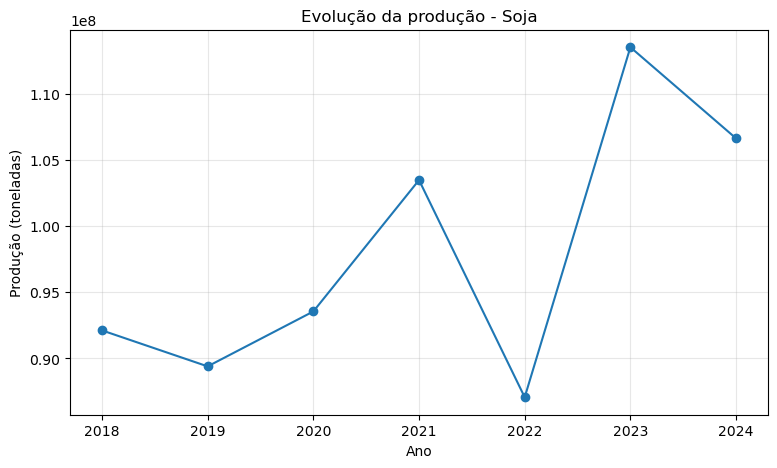

In [42]:
import matplotlib.pyplot as plt

for cultura in producao_anual["cultura"].unique():
    dados = producao_anual[
        producao_anual["cultura"] == cultura
    ]

    plt.figure(figsize=(9, 5))

    plt.plot(
        dados["ano"],
        dados["quantidade_produzida_t"],
        marker="o"
    )

    plt.title(
        f"Evolução da produção - {cultura.capitalize()}"
    )

    plt.xlabel("Ano")
    plt.ylabel("Produção (toneladas)")
    plt.grid(alpha=0.3)

    plt.show()


In [43]:
producao_uf = (
    pam_processado
    .groupby(
        ["uf", "cultura"],
        as_index=False
    )
    ["quantidade_produzida_t"]
    .sum()
)

producao_uf.head()


,uf,cultura,quantidade_produzida_t
0,DF,soja,2016480.0
1,GO,soja,98662100.0
2,MS,soja,75768574.0
3,MT,soja,255105628.0
4,PR,soja,129163069.0


In [44]:
(
    producao_uf[
        producao_uf["cultura"] == "soja"
    ]
    .sort_values(
        "quantidade_produzida_t",
        ascending=False
    )
    .head(10)
)


,uf,cultura,quantidade_produzida_t
3,MT,soja,255105628.0
4,PR,soja,129163069.0
5,RS,soja,108052140.0
1,GO,soja,98662100.0
2,MS,soja,75768574.0
6,SC,soja,17021171.0
0,DF,soja,2016480.0


In [45]:
(
    pam_processado[
        pam_processado["cultura"] == "soja"
    ]
    .groupby(
        ["codigo_ibge", "municipio", "uf"],
        as_index=False
    )
    ["quantidade_produzida_t"]
    .sum()
    .sort_values(
        "quantidade_produzida_t",
        ascending=False
    )
    .head(20)
)


,codigo_ibge,municipio,uf,quantidade_produzida_t
1252,5107925,Sorriso,MT,15115545.0
1456,5218805,Rio Verde,GO,10112000.0
1207,5106240,Nova Ubiratã,MT,9612752.0
1152,5102637,Campo Novo do Parecis,MT,9390305.0
1205,5106224,Nova Mutum,MT,9375362.0
1249,5107875,Sapezal,MT,8860577.0
1170,5103502,Diamantino,MT,8704183.0
1228,5107065,Querência,MT,8603904.0
1390,5211909,Jataí,GO,7814900.0
1103,5005400,Maracaju,MS,7417132.0


In [46]:
regioes_projeto = ["Centro-Oeste", "Sul"]
ufs_projeto = ["DF", "GO", "MT", "MS", "PR", "RS", "SC"]

assert set(pam_processado["regiao"].dropna().unique()) <= set(regioes_projeto)
assert set(pam_processado["uf"].dropna().unique()) <= set(ufs_projeto)
assert set(pam_processado["cultura"].dropna().unique()) == {"soja"}

print("✅ Escopo territorial e cultura validados.")


✅ Escopo territorial e cultura validados.


In [47]:
pam_processado[
    ["uf", "regiao"]
].drop_duplicates().sort_values(
    ["regiao", "uf"]
)


,uf,regiao
10068,DF,Centro-Oeste
8563,GO,Centro-Oeste
7142,MS,Centro-Oeste
7680,MT,Centro-Oeste
0,PR,Sul
4145,RS,Sul
2690,SC,Sul


In [48]:
pam_processado["regiao"].isna().sum()


np.int64(0)

In [49]:
producao_regiao = (
    pam_processado
    .groupby(
        ["regiao", "ano", "cultura"],
        as_index=False
    )
    ["quantidade_produzida_t"]
    .sum()
)

producao_regiao.head(20)


,regiao,ano,cultura,quantidade_produzida_t
0,Centro-Oeste,2018,soja,53208000.0
1,Centro-Oeste,2019,soja,52281916.0
2,Centro-Oeste,2020,soja,59149426.0
3,Centro-Oeste,2021,soja,61535453.0
4,Centro-Oeste,2022,soja,62083262.0
5,Centro-Oeste,2023,soja,76330093.0
6,Centro-Oeste,2024,soja,66964632.0
7,Sul,2018,soja,38912491.0
8,Sul,2019,soja,37116995.0
9,Sul,2020,soja,34403141.0


In [50]:
duplicados_final = (
    pam_processado
    .duplicated(
        subset=[
            "codigo_ibge",
            "ano",
            "cultura"
        ]
    )
    .sum()
)

print(
    "Duplicados na chave município-ano-cultura:",
    duplicados_final
)


Duplicados na chave município-ano-cultura: 0


In [51]:
pam_processado.isna().sum().sort_values(
    ascending=False
)


area_colhida_ha             5
quantidade_produzida_t      5
rendimento_medio_kg_ha      5
valor_producao_mil_reais    5
aproveitamento_area_pct     5
area_nao_colhida_ha         5
codigo_ibge                 0
municipio                   0
uf                          0
ano                         0
cultura                     0
area_plantada_ha            0
regiao                      0
dtype: int64

In [52]:
pam_processado = pam_processado[
    [
        "codigo_ibge",
        "municipio",
        "uf",
        "regiao",
        "ano",
        "cultura",
        "area_plantada_ha",
        "area_colhida_ha",
        "area_nao_colhida_ha",
        "aproveitamento_area_pct",
        "quantidade_produzida_t",
        "rendimento_medio_kg_ha",
        "valor_producao_mil_reais"
    ]
].copy()


In [53]:
pam_processado.head()


,codigo_ibge,municipio,uf,regiao,ano,cultura,area_plantada_ha,area_colhida_ha,area_nao_colhida_ha,aproveitamento_area_pct,quantidade_produzida_t,rendimento_medio_kg_ha,valor_producao_mil_reais
0,4100103,Abatiá,PR,Sul,2018,soja,10220.0,10220.0,0.0,100.0,26981.0,2640.0,29517.0
1,4100103,Abatiá,PR,Sul,2019,soja,10570.0,10570.0,0.0,100.0,36784.0,3480.0,43387.0
2,4100103,Abatiá,PR,Sul,2020,soja,10470.0,10470.0,0.0,100.0,36435.0,3480.0,50268.0
3,4100103,Abatiá,PR,Sul,2021,soja,10220.0,10220.0,0.0,100.0,27727.0,2713.0,69682.0
4,4100103,Abatiá,PR,Sul,2022,soja,10470.0,10470.0,0.0,100.0,37064.0,3540.0,114457.0


In [54]:
print("Linhas:", len(pam_processado))

print(
    "Municípios:",
    pam_processado["codigo_ibge"].nunique()
)

print(
    "Anos:",
    sorted(pam_processado["ano"].unique())
)

print(
    "Culturas:",
    pam_processado["cultura"].unique()
)

print(
    "Regiões:",
    pam_processado["regiao"].unique()
)


Linhas: 10075
Municípios: 1505
Anos: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Culturas: <StringArray>
['soja']
Length: 1, dtype: string
Regiões: ['Sul' 'Centro-Oeste']


# 9. Construção da camada Curated

A camada `Processed` já está restrita à soja e às regiões Centro-Oeste e Sul.
A camada `Curated` aplica o período analítico de 2019 a 2024 e mantém o mesmo recorte territorial e cultural.


In [55]:
pam_curated = pam_processado.copy()

print("Dimensão da camada Processed:", pam_processado.shape)
print("Dimensão inicial da camada Curated:", pam_curated.shape)


Dimensão da camada Processed: (10075, 13)
Dimensão inicial da camada Curated: (10075, 13)


In [56]:
pam_curated = (
    pam_curated[
        pam_curated["ano"].between(2019, 2024)
    ]
    .copy()
)

print(
    "Anos da camada Curated:",
    sorted(pam_curated["ano"].unique())
)


Anos da camada Curated: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


In [57]:
culturas_projeto = ["soja"]

pam_curated = pam_curated[
    pam_curated["cultura"].isin(culturas_projeto)
].copy()

print("Culturas:", pam_curated["cultura"].unique())


Culturas: <StringArray>
['soja']
Length: 1, dtype: string


In [58]:
regioes_projeto = ["Centro-Oeste", "Sul"]

pam_curated = pam_curated[
    pam_curated["regiao"].isin(regioes_projeto)
].copy()

print("Regiões:", sorted(pam_curated["regiao"].unique()))


Regiões: ['Centro-Oeste', 'Sul']


In [59]:
print(
    pam_curated["regiao"]
    .value_counts(dropna=False)
)

print(
    "\nRegiões:",
    pam_curated["regiao"].unique()
)


regiao
Sul             6141
Centro-Oeste    2533
Name: count, dtype: int64

Regiões: ['Sul' 'Centro-Oeste']


In [60]:
pam_curated["area_nao_colhida_ha"] = (
    pam_curated["area_plantada_ha"]
    - pam_curated["area_colhida_ha"]
)


In [61]:
import numpy as np

pam_curated["aproveitamento_area_pct"] = np.where(
    pam_curated["area_plantada_ha"] > 0,
    (
        pam_curated["area_colhida_ha"]
        / pam_curated["area_plantada_ha"]
        * 100
    ),
    np.nan
)


In [62]:
pam_curated[
    [
        "codigo_ibge",
        "municipio",
        "uf",
        "regiao",
        "ano",
        "cultura",
        "area_plantada_ha",
        "area_colhida_ha",
        "area_nao_colhida_ha",
        "aproveitamento_area_pct",
        "quantidade_produzida_t",
        "rendimento_medio_kg_ha",
        "valor_producao_mil_reais"
    ]
].head(10)


,codigo_ibge,municipio,uf,regiao,ano,cultura,area_plantada_ha,area_colhida_ha,area_nao_colhida_ha,aproveitamento_area_pct,quantidade_produzida_t,rendimento_medio_kg_ha,valor_producao_mil_reais
1,4100103,Abatiá,PR,Sul,2019,soja,10570.0,10570.0,0.0,100.0,36784.0,3480.0,43387.0
2,4100103,Abatiá,PR,Sul,2020,soja,10470.0,10470.0,0.0,100.0,36435.0,3480.0,50268.0
3,4100103,Abatiá,PR,Sul,2021,soja,10220.0,10220.0,0.0,100.0,27727.0,2713.0,69682.0
4,4100103,Abatiá,PR,Sul,2022,soja,10470.0,10470.0,0.0,100.0,37064.0,3540.0,114457.0
5,4100103,Abatiá,PR,Sul,2023,soja,9960.0,9960.0,0.0,100.0,35856.0,3600.0,94498.0
6,4100103,Abatiá,PR,Sul,2024,soja,9600.0,9600.0,0.0,100.0,34560.0,3600.0,66365.0
7,4100202,Adrianópolis,PR,Sul,2023,soja,20.0,20.0,0.0,100.0,70.0,3500.0,206.0
8,4100202,Adrianópolis,PR,Sul,2024,soja,18.0,18.0,0.0,100.0,61.0,3389.0,132.0
10,4100301,Agudos do Sul,PR,Sul,2019,soja,1450.0,1450.0,0.0,100.0,5365.0,3700.0,6138.0
11,4100301,Agudos do Sul,PR,Sul,2020,soja,1840.0,1840.0,0.0,100.0,7084.0,3850.0,9918.0


In [63]:
colunas_curated = [
    "codigo_ibge",
    "municipio",
    "uf",
    "regiao",
    "ano",
    "cultura",
    "area_plantada_ha",
    "area_colhida_ha",
    "area_nao_colhida_ha",
    "aproveitamento_area_pct",
    "quantidade_produzida_t",
    "rendimento_medio_kg_ha",
    "valor_producao_mil_reais"
]

pam_curated = (
    pam_curated[colunas_curated]
    .sort_values(
        [
            "codigo_ibge",
            "ano",
            "cultura"
        ]
    )
    .reset_index(drop=True)
)

pam_curated.head()


,codigo_ibge,municipio,uf,regiao,ano,cultura,area_plantada_ha,area_colhida_ha,area_nao_colhida_ha,aproveitamento_area_pct,quantidade_produzida_t,rendimento_medio_kg_ha,valor_producao_mil_reais
0,4100103,Abatiá,PR,Sul,2019,soja,10570.0,10570.0,0.0,100.0,36784.0,3480.0,43387.0
1,4100103,Abatiá,PR,Sul,2020,soja,10470.0,10470.0,0.0,100.0,36435.0,3480.0,50268.0
2,4100103,Abatiá,PR,Sul,2021,soja,10220.0,10220.0,0.0,100.0,27727.0,2713.0,69682.0
3,4100103,Abatiá,PR,Sul,2022,soja,10470.0,10470.0,0.0,100.0,37064.0,3540.0,114457.0
4,4100103,Abatiá,PR,Sul,2023,soja,9960.0,9960.0,0.0,100.0,35856.0,3600.0,94498.0


## 10. Validação da camada Curated

Antes da exportação são verificadas as regras de negócio aplicadas,
a unicidade da chave município-ano-cultura, o período temporal,
as culturas selecionadas e a classificação regional.


In [64]:
print("Dimensão:", pam_curated.shape)

print(
    "Municípios:",
    pam_curated["codigo_ibge"].nunique()
)

print(
    "Anos:",
    sorted(pam_curated["ano"].unique())
)

print(
    "Culturas:",
    pam_curated["cultura"].unique()
)

print(
    "Regiões:",
    pam_curated["regiao"].unique()
)


Dimensão: (8674, 13)
Municípios: 1505
Anos: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Culturas: <StringArray>
['soja']
Length: 1, dtype: string
Regiões: ['Sul' 'Centro-Oeste']


In [65]:
duplicados_curated = (
    pam_curated
    .duplicated(
        subset=[
            "codigo_ibge",
            "ano",
            "cultura"
        ]
    )
    .sum()
)

print(
    "Duplicados na chave município-ano-cultura:",
    duplicados_curated
)


Duplicados na chave município-ano-cultura: 0


In [66]:
regioes_ausentes = (
    pam_curated["regiao"]
    .isna()
    .sum()
)

print(
    "Regiões ausentes:",
    regioes_ausentes
)


Regiões ausentes: 0


# 11. Exportação das camadas de dados

São gerados dois datasets consistentes com o escopo corrigido:

- `Processed`: soja, Centro-Oeste e Sul, período 2018–2024;
- `Curated`: soja, Centro-Oeste e Sul, período 2019–2024.


In [67]:
from pathlib import Path

BASE_DIR = Path.cwd().parent

print("Raiz do projeto:")
print(BASE_DIR)


Raiz do projeto:
C:\Users\Elaine Cristina\Downloads\agroesg-analytics_correcao\agroesg-analytics_correcao


In [68]:
PROCESSED_DIR = (
    BASE_DIR
    / "data"
    / "databases_processed"
    / "ibge_pam"
)

CURATED_DIR = (
    BASE_DIR
    / "data"
    / "databases_curated"
    / "ibge_pam"
)

PROCESSED_DIR.mkdir(
    parents=True,
    exist_ok=True
)

CURATED_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Processed:", PROCESSED_DIR)
print("Curated:", CURATED_DIR)


Processed: C:\Users\Elaine Cristina\Downloads\agroesg-analytics_correcao\agroesg-analytics_correcao\data\databases_processed\ibge_pam
Curated: C:\Users\Elaine Cristina\Downloads\agroesg-analytics_correcao\agroesg-analytics_correcao\data\databases_curated\ibge_pam


In [69]:
arquivo_processed = (
    PROCESSED_DIR
    / "pam_processed_soja_centro_oeste_sul_2018_2024.csv"
)

pam_processado.to_csv(arquivo_processed, index=False, encoding="utf-8-sig")
print("Processed salvo em:", arquivo_processed)


Processed salvo em: C:\Users\Elaine Cristina\Downloads\agroesg-analytics_correcao\agroesg-analytics_correcao\data\databases_processed\ibge_pam\pam_processed_soja_centro_oeste_sul_2018_2024.csv


In [70]:
arquivo_curated = (
    CURATED_DIR
    / "pam_curated_soja_centro_oeste_sul_2019_2024.csv"
)

pam_curated.to_csv(arquivo_curated, index=False, encoding="utf-8-sig")
print("Curated salvo em:", arquivo_curated)


Curated salvo em: C:\Users\Elaine Cristina\Downloads\agroesg-analytics_correcao\agroesg-analytics_correcao\data\databases_curated\ibge_pam\pam_curated_soja_centro_oeste_sul_2019_2024.csv


In [71]:
print(
    "Processed existe?",
    arquivo_processed.exists()
)

print(
    "Curated existe?",
    arquivo_curated.exists()
)


Processed existe? True
Curated existe? True


In [72]:
teste_processed = pd.read_csv(
    arquivo_processed,
    dtype={
        "codigo_ibge": "string"
    }
)

teste_curated = pd.read_csv(
    arquivo_curated,
    dtype={
        "codigo_ibge": "string"
    }
)

print(
    "Processed:",
    teste_processed.shape
)

print(
    "Curated:",
    teste_curated.shape
)


Processed: (10075, 13)
Curated: (8674, 13)


In [73]:
assert teste_processed["ano"].min() == 2018
assert teste_processed["ano"].max() == 2024
assert teste_curated["ano"].min() == 2019
assert teste_curated["ano"].max() == 2024

assert set(teste_processed["cultura"].unique()) == {"soja"}
assert set(teste_curated["cultura"].unique()) == {"soja"}
assert set(teste_processed["regiao"].unique()) == {"Centro-Oeste", "Sul"}
assert set(teste_curated["regiao"].unique()) == {"Centro-Oeste", "Sul"}
assert set(teste_curated["uf"].unique()) <= {"DF", "GO", "MT", "MS", "PR", "RS", "SC"}

print("✅ Camadas Processed e Curated exportadas e validadas com sucesso.")


✅ Camadas Processed e Curated exportadas e validadas com sucesso.


# Conclusão

A base PAM/IBGE foi tratada para o novo escopo do projeto: **soja**, regiões **Centro-Oeste** e **Sul** e seus respectivos municípios.

A camada `Processed` cobre 2018–2024 e a camada `Curated` cobre 2019–2024. Ambas preservam `codigo_ibge`, município, UF e região, permitindo integração reprodutível com o MapBiomas Solo.
